# HEFS Forecast, Storage, and Outflow Module
<small><em>
Prepared as a part of Hydrolearn module  
Authors: Sujana Timilsina, Suma Bhanu Batulla
</em></small>


The notebook produces:

1. HEFS ensemble volume ranking for the selected time window.
2. Representative ensemble traces based on selected non-exceedance probabilities.
3. Selected-trace inflow plots.
4. Expected storage-rise time series for the selected traces.
5. Forecast storage compared with the guide curve.
6. Additional outflow needed to stay below the guide curve.
7. Actual observed outflow compared with the calculated additional outflow need.

> **Important:** The storage-rise calculation in this notebook assumes the cumulative selected HEFS inflow volume is the expected storage rise. If the module should account for releases, evaporation, routing, or other reservoir operations, modification is needed in the `compute_storage_rise_timeseries()` function.


## Quick start

1. Place this notebook in the same folder as the input files, or update the file paths in the **User Inputs** cell.
2. Edit `analysis_start` and `analysis_end` to select the forecast time frame.
3. Edit `target_percentiles` to select the representative ensemble traces.
4. Run all cells.

Examples for `target_percentiles`:

```python
{"P05": 0.05, "P50": 0.50, "P95": 0.95}
```

or, for quartiles:

```python
{"P25": 0.25, "P50": 0.50, "P75": 0.75}
```


---
### Load the Python tools (setup)

This first code cell loads the outside libraries the notebook depends on:
`numpy` for math, `pandas` for working with tables, `matplotlib` for charts,
`requests` for downloading files from the web, plus a few standard helpers for
file paths, zip files, and dates. It also sets a default size and a light grid
for every chart so the figures look consistent, and silences a category of
harmless warning messages.

In [27]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile, re
import pandas as pd
from pathlib import Path
import requests
from pathlib import Path
from datetime import datetime

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore", category=FutureWarning)

# Use a consistent default figure size throughout the module.
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.35

## User Inputs (This is the place to enter your choice of station, forecast dates and analysis period )

This is the **only cell you normally edit**. Set the forecast issuance
(`station`, `issue_date`, `cycle`, `group`, `kind`) and the analysis window
(`analysis_start`, `analysis_end`). Everything downstream is automatic:

- the correct CNRFC file is **downloaded** from `issue_date` + `cycle` + `group` + `kind`,
- the single-station ensemble is **extracted** and **named** automatically
  (`<station>_HEFS_<kind>_<YYYYMMDDHH>_extracted.csv`), and
- the analysis runs for the window you chose.

For Lake Mendocino use `station = "LAMC1"`. Change `issue_date` / `cycle` to
analyze a different storm issuance; no other cell needs editing.
**What you'll see when you run the next cell:** it prints the auto-built
`forecast_date_label`, `raw_zip_name`, and `hefs_file`, then displays the full
`CONFIG` dictionary so you can confirm your settings. No chart.


For the current module, set the issue_date to 2025-01-29 and modify the analysis start date as January 29, 2025 and analysis end date as February 21, 2025.

In [28]:
# ==================================================
# USER INPUTS  --  single source of truth
# ==================================================
# To run a new event you normally edit ONLY the fields in this cell.
# The forecast file is downloaded, extracted, and named automatically from
# issue_date + cycle + group + kind + station (see derive_paths() below).

CONFIG = {
    # --- Forecast issuance (drives the automatic download) ---
    "station": "LAMC1",          # CNRFC station id (LAMC1 = Lake Mendocino)
    "issue_date": "2025-01-10",  # HEFS issuance date, YYYY-MM-DD
    "cycle": "12",               # issuance cycle, Z/UTC hour (CNRFC issues HEFS at 12Z)
    "group": "RussianNapa",      # CNRFC forecast group the station belongs to
    "kind": "hourly",            # "hourly" (30-day) or "daily" (365-day)

    # --- Analysis window (sub-window of the forecast to analyze) ---
    # HEFS/GMT times are treated as UTC.
    "analysis_start": "2025-01-10 12:00",
    "analysis_end":   "2025-01-20 12:00",

    # --- Representative traces (non-exceedance probabilities) ---
    # 0.05 = lower-flow trace, 0.50 = median, 0.95 = high-flow.
    "target_percentiles": {
        "P05": 0.05,
        "P50": 0.50,
        "P95": 0.95,
    },

    # --- Observed data files (storage / outflow comparison) ---
    "observed_storage_file": "COY_15_2025.xlsx",
    "observed_outflow_file": "COY_23_2025.xlsx",

    # --- Output folder ---
    "output_dir": "outputs",

    # --- HEFS file settings ---
    "hefs_time_col": "GMT",
    "ensemble_prefix": "ensemble_",
    "hefs_flow_units": "kcfs",  # "kcfs" or "cfs"

    # --- Reservoir guide curve ---
    "guide_curve_storage_acreft": 68400,

    
    # ------------------------------------------------
    # Observed-data download (CDEC)
    # ------------------------------------------------
    # Observed storage (sensor 15) and outflow (sensor 23) can be downloaded
    # automatically from the California Data Exchange Center (CDEC) for a chosen
    # water year. A water year spans Oct 1 (previous calendar year) -> Sep 30.
    #   Example: water_year = 2025  ->  2024-10-01 to 2025-09-30
    # When download_observed_data is True, the two "observed_*_file" paths above
    # are overwritten automatically with the freshly downloaded files, and the
    # storage/outflow timezones are set to Pacific (CDEC timestamps are Pacific).
    "download_observed_data": True,    # set False to use existing local files
    "water_year": 2025,
    "cdec_station": "COY",             # Coyote Valley Dam / Lake Mendocino
    "cdec_storage_sensor": 15,         # RESERVOIR STORAGE, AF
    "cdec_outflow_sensor": 23,         # RESERVOIR OUTFLOW, CFS
    "cdec_dur_code": "H",              # E = event, H = hourly, D = daily
    "cdec_download_dir": ".",          # folder to save downloaded files
    "cdec_timezone": "America/Los_Angeles",

    # --- Time-zone handling ---
    # HEFS timestamps are assumed UTC because the source column is GMT.
    # storage_timezone: None compares Excel timestamps as written;
    # use "America/Los_Angeles" if those timestamps are local Pacific time.
    "storage_timezone": None,
    "observed_outflow_timezone": "America/Los_Angeles",

    # --- Actual-vs-required outflow comparison settings ---
    "comparison_timezone": "UTC",
    "observed_outflow_buffer": "3 hours",
    "merge_tolerance": "1 hour",

    # --- Output controls ---
    "save_csv": True,
    "save_figures": True,
    "figure_dpi": 200,

    # --- Download controls ---
    # A HEFS issuance is immutable once issued, so the raw .zip is cached by
    # name and reused on re-runs. Set True to force a fresh download.
    "redownload_if_exists": False,

    # --- Workflow controls ---
    "run_hefs_selection": True,
    "run_storage_analysis": True,
    "run_actual_outflow_comparison": True,
}


def derive_paths(config):
    """Derive every date-dependent name from the issuance fields above.

    Populates raw_zip_name / raw_zip_url (download), forecast_date_label
    (plot titles), and hefs_file (extracted single-station ensemble that the
    analysis reads). Idempotent: safe to re-run after editing CONFIG.
    """
    issue = datetime.strptime(config["issue_date"], "%Y-%m-%d")
    ymd = issue.strftime("%Y%m%d")
    cycle = str(config["cycle"]).zfill(2)

    config["raw_zip_name"] = f"{ymd}{cycle}_{config['group']}_hefs_csv_{config['kind']}.zip"
    config["raw_zip_url"]  = f"https://www.cnrfc.noaa.gov/csv/{config['raw_zip_name']}"
    config["forecast_date_label"] = f"{config['issue_date']} {cycle}Z"
    config["hefs_file"] = (
        f"{config['station']}_HEFS_{config['kind']}_{ymd}{cycle}_extracted.csv"
    )
    return config


CONFIG = derive_paths(CONFIG)
print("forecast_date_label:", CONFIG["forecast_date_label"])
print("raw_zip_name       :", CONFIG["raw_zip_name"])
print("hefs_file          :", CONFIG["hefs_file"])
CONFIG


forecast_date_label: 2025-01-29 12Z
raw_zip_name       : 2025012912_RussianNapa_hefs_csv_hourly.zip
hefs_file          : LAMC1_HEFS_hourly_2025012912_extracted.csv


{'station': 'LAMC1',
 'issue_date': '2025-01-29',
 'cycle': '12',
 'group': 'RussianNapa',
 'kind': 'hourly',
 'analysis_start': '2025-01-29 12:00',
 'analysis_end': '2025-02-21 12:00',
 'target_percentiles': {'P05': 0.05, 'P50': 0.5, 'P95': 0.95},
 'observed_storage_file': 'COY_15_2025.xlsx',
 'observed_outflow_file': 'COY_23_2025.xlsx',
 'output_dir': 'outputs',
 'hefs_time_col': 'GMT',
 'ensemble_prefix': 'ensemble_',
 'hefs_flow_units': 'kcfs',
 'guide_curve_storage_acreft': 68400,
 'download_observed_data': True,
 'water_year': 2025,
 'cdec_station': 'COY',
 'cdec_storage_sensor': 15,
 'cdec_outflow_sensor': 23,
 'cdec_dur_code': 'H',
 'cdec_download_dir': '.',
 'cdec_timezone': 'America/Los_Angeles',
 'storage_timezone': None,
 'observed_outflow_timezone': 'America/Los_Angeles',
 'comparison_timezone': 'UTC',
 'observed_outflow_buffer': '3 hours',
 'merge_tolerance': '1 hour',
 'save_csv': True,
 'save_figures': True,
 'figure_dpi': 200,
 'redownload_if_exists': False,
 'run_hefs

## Download the HEFS data 
This cell fetches the CNRFC issuance selected in the inputs above. Driven entirely by
`CONFIG` — nothing to edit here. The raw `.zip` is cached by name and reused
on re-runs unless `CONFIG["redownload_if_exists"]` is `True`.
**What you'll see when you run the next cell:** one or two printed lines telling
you either that a cached file was reused or that a fresh file was downloaded,
plus the file size in MB. No chart.


In [29]:
# --- Download the CNRFC HEFS ensemble issuance for the selected forecast ---
# Driven entirely by CONFIG (issue_date / cycle / group / kind). No manual edits.

try:
    SCRIPT_DIR = Path(__file__).resolve().parent
except NameError:
    SCRIPT_DIR = Path.cwd()

dest = SCRIPT_DIR / CONFIG["raw_zip_name"]   # used by the extraction cell below
url  = CONFIG["raw_zip_url"]

if dest.exists() and not CONFIG.get("redownload_if_exists", False):
    print(f"using cached file -> {dest}  ({dest.stat().st_size/1e6:.2f} MB)")
    print("(set CONFIG['redownload_if_exists'] = True to force a fresh download)")
else:
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()
    dest.write_bytes(resp.content)
    print(f"downloaded {url}\nsaved -> {dest}  ({dest.stat().st_size/1e6:.2f} MB)")


downloaded https://www.cnrfc.noaa.gov/csv/2025012912_RussianNapa_hefs_csv_hourly.zip
saved -> /Users/sujanatimilsina/Documents/Sujana_PhD/Hydrolearn/Resources/Test/2025012912_RussianNapa_hefs_csv_hourly.zip  (3.17 MB)


---
Pull out one station's inflow forecast

The file you just downloaded contains forecasts for *many* stations and 44
ensemble **members** (think of each member as one plausible "what-if" version of
the future). This cell opens that big file, keeps only the *inflow* columns for
the station you chose (`LAMC1`), renames those columns based on the historical year order `1980` …
`2023`, and saves the trimmed result as a clean CSV that the rest of the
notebook can read.

**What you'll see when you run it:** a one-line summary such as
`LAMC1: 44 members x N rows -> ..._extracted.csv`, followed by a preview of the
first five rows of the new table (a time column plus the 44 ensemble columns).

In [30]:
# --- Extract one station's ensemble from the raw CNRFC file into the CONFIG schema ---


RAW_PATH = dest                 # the .zip from the download cell; or Path("...some.csv")
STATION  = CONFIG["station"]
INFLOW_PARAMS = ("QINE", "SQIN")   # SHEF inflow codes; excludes stage (SSTG) / local (*L)

# read the raw grid from a .zip or an already-extracted .csv
p = Path(RAW_PATH)
if p.suffix.lower() == ".zip":
    with zipfile.ZipFile(p) as z:
        name = next(n for n in z.namelist() if n.lower().endswith(".csv"))
        text = z.read(name).decode("utf-8", "replace")
else:
    text = p.read_text(encoding="utf-8", errors="replace")
grid = [ln.rstrip("\n").split(",") for ln in text.splitlines() if ln.strip()]

station_row, param_row = grid[0], grid[1]
first = next(i for i, r in enumerate(grid) if r and re.match(r"\d{4}-\d{2}-\d{2}", r[0].strip()))

# columns for this station that carry inflow
cols = [j for j in range(1, len(station_row))
        if station_row[j].strip().upper() == STATION.upper()
        and (j >= len(param_row) or not param_row[j].strip()
             or param_row[j].strip().upper() in INFLOW_PARAMS)]

data_rows = [r for r in grid[first:] if r and r[0].strip()]
out = pd.DataFrame({CONFIG["hefs_time_col"]: [r[0].strip() for r in data_rows]})
for k, j in enumerate(cols):
    vals = []
    for r in data_rows:
        try:    vals.append(float(r[j]))
        except (ValueError, IndexError): vals.append(float("nan"))
    # CNRFC HEFS columns are in historical-year order: first member = start year.
    # Name each member by its year (1980 ... 2023) so traces are self-identifying.
    year = int(CONFIG.get("ensemble_start_year", 1980)) + k
    out[str(year)] = vals   # 1980 ... 2023

out_path = Path(CONFIG["hefs_file"])
out.to_csv(out_path, index=False)
start_year = int(CONFIG.get("ensemble_start_year", 1980))
end_year = start_year + len(cols) - 1
print(f"{STATION}: {len(cols)} members x {len(out)} rows -> {out_path}")
print(f"  members named by historical year: {start_year} ... {end_year}")
if len(cols) != 44:
    print(f"  WARNING: expected 44 members (1980-2023) but found {len(cols)}. "
          "Check CONFIG['ensemble_start_year'] and the raw CNRFC file.")
out.head()

LAMC1: 44 members x 721 rows -> LAMC1_HEFS_hourly_2025012912_extracted.csv
  members named by historical year: 1980 ... 2023


,GMT,1980,1981,1982,1983,1984,1985,1986,1987,1988,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,2025-01-29 12:00:00,0.08701,0.08701,0.08701,0.08701,0.08701,0.08701,0.08701,0.08701,0.08701,...,0.08701,0.08701,0.08701,0.08701,0.08701,0.08701,0.08701,0.08701,0.08701,0.08701
1,2025-01-29 13:00:00,0.08693,0.08693,0.08693,0.08693,0.08693,0.08693,0.08693,0.08693,0.08693,...,0.08693,0.08693,0.08693,0.08693,0.08693,0.08693,0.08693,0.08693,0.08693,0.08693
2,2025-01-29 14:00:00,0.08686,0.08686,0.08686,0.08686,0.08686,0.08686,0.08686,0.08686,0.08686,...,0.08686,0.08686,0.08686,0.08686,0.08686,0.08686,0.08686,0.08686,0.08686,0.08686
3,2025-01-29 15:00:00,0.08679,0.08679,0.08679,0.08679,0.08679,0.08679,0.08679,0.08679,0.08679,...,0.08679,0.08679,0.08679,0.08679,0.08679,0.08679,0.08679,0.08679,0.08679,0.08679
4,2025-01-29 16:00:00,0.08671,0.08671,0.08671,0.08671,0.08671,0.08671,0.08671,0.08671,0.08671,...,0.08671,0.08671,0.08671,0.08671,0.08671,0.08671,0.08671,0.08671,0.08671,0.08671


---
Check the available forecast time range

A quick sanity check before doing any real analysis. It opens the extracted
file and reports the earliest timestamp, the latest timestamp, and the number of
rows. Use this to confirm that the analysis window you set in **User Inputs**
(`analysis_start` / `analysis_end`) actually falls inside the forecast period.

**What you'll see when you run it:** three printed lines — **Start**, **End**,
and **Rows**. No chart.

In [31]:
def preview_hefs_time_range(config):
    """Preview available HEFS time range before running the full workflow."""
    file_path = Path(config["hefs_file"])
    if not file_path.exists():
        raise FileNotFoundError(
            f"HEFS file not found: {file_path}\n"
            "Place the file in this folder or update CONFIG['hefs_file']."
        )

    time_col = config["hefs_time_col"]
    df_preview = pd.read_csv(file_path, usecols=[time_col])
    df_preview[time_col] = pd.to_datetime(df_preview[time_col])

    print("Available HEFS time range")
    print("-------------------------")
    print("Start:", df_preview[time_col].min())
    print("End:  ", df_preview[time_col].max())
    print("Rows: ", len(df_preview))

# Optional:
preview_hefs_time_range(CONFIG)

Available HEFS time range
-------------------------
Start: 2025-01-29 12:00:00
End:   2025-02-28 12:00:00
Rows:  721


---
### Helper functions (setup only)

This cell *defines* a set of small, reusable helper functions but does not run
an analysis yet. They handle the repetitive plumbing used later: converting flow
units into acre-feet, cleaning messy number columns, fixing time zones, building
output file names, saving CSVs and figures, and checking that required files and
columns are present.

**What you'll see when you run it:** nothing visible. Defining functions
produces no output on screen — that's normal and expected. You're just teaching
the notebook these tools so later cells can call them.

In [32]:
# ==================================================
# UTILITY FUNCTIONS
# ==================================================

def get_config(config, key, default=None):
    return config[key] if key in config else default


def as_path(value):
    return Path(value).expanduser()


def ensure_output_dir(config):
    output_dir = as_path(config["output_dir"])
    output_dir.mkdir(parents=True, exist_ok=True)
    return output_dir


def parse_timestamp(value):
    return pd.Timestamp(value)


def make_window_label(start_time, end_time):
    start = pd.Timestamp(start_time)
    end = pd.Timestamp(end_time)
    return f"{start:%Y%m%d%H}_to_{end:%Y%m%d%H}"


def check_input_file(file_path, label):
    file_path = as_path(file_path)
    if not file_path.exists():
        raise FileNotFoundError(
            f"{label} not found: {file_path}\n"
            "Place the file in the notebook folder or update the corresponding CONFIG path."
        )
    return file_path


def flow_hour_to_acreft_factor(flow_units):
    """
    Return acre-ft per one unit of flow sustained for one hour.

    cfs  for one hour = 3600 / 43560 acre-ft
    kcfs for one hour = 1000 * 3600 / 43560 acre-ft
    """
    units = str(flow_units).lower()
    cfs_hour_to_acreft = 3600 / 43560

    if units == "cfs":
        return cfs_hour_to_acreft
    if units == "kcfs":
        return 1000 * cfs_hour_to_acreft

    raise ValueError("CONFIG['hefs_flow_units'] must be either 'cfs' or 'kcfs'.")


def clean_numeric_series(series):
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False),
        errors="coerce"
    )


def localize_convert_to_utc_naive(time_series, source_timezone):
    """
    Convert timestamps to UTC and remove timezone information.

    If source_timezone is None, timestamps are returned as timezone-naive
    without conversion.
    """
    times = pd.to_datetime(time_series)

    if source_timezone is None:
        return times

    # If timestamps are timezone-naive, localize first.
    if times.dt.tz is None:
        localized = times.dt.tz_localize(
            source_timezone,
            ambiguous="NaT",
            nonexistent="shift_forward"
        )
    else:
        localized = times

    converted = localized.dt.tz_convert("UTC").dt.tz_localize(None)
    return converted


def show_and_optionally_save(fig, output_dir, filename, config):
    fig.tight_layout()

    if config.get("save_figures", True):
        output_path = output_dir / filename
        fig.savefig(output_path, dpi=config.get("figure_dpi", 200), bbox_inches="tight")
        print(f"Figure saved: {output_path}")

    plt.show()


def save_csv_if_requested(df, output_dir, filename, config):
    output_path = output_dir / filename
    if config.get("save_csv", True):
        df.to_csv(output_path, index=False)
        print(f"CSV saved: {output_path}")
    return output_path


def require_columns(df, required_cols, file_label):
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(
            f"{file_label} is missing required column(s): {missing}\n"
            f"Available columns: {list(df.columns)}"
        )

## Download observed reservoir data (CDEC)

This section downloads observed reservoir **storage** (sensor 15) and **outflow**
(sensor 23) for the station and **water year** chosen in the User Inputs cell,
directly from the [CDEC web service](https://cdec.water.ca.gov/).

It saves the data into the same `DATE TIME` / `VALUE` format the loaders below
expect, then points `CONFIG["observed_storage_file"]` and
`CONFIG["observed_outflow_file"]` at the downloaded files. To skip downloading
and use local files instead, set `CONFIG["download_observed_data"] = False`.

> Requires internet access to `cdec.water.ca.gov`. CDEC timestamps are Pacific
> local time, so the storage/outflow timezones are set accordingly after download.

> **Note for learners:** the next cell only *defines* the download functions —
> running it shows nothing. The download actually happens in the cell after that,
> which prints the request links, row counts, and saved file locations.


In [33]:
# ==================================================
# OBSERVED-DATA DOWNLOAD (CDEC)
# ==================================================
# CDEC CSV web service (example):
#   https://cdec.water.ca.gov/dynamicapp/req/CSVDataServlet
#       ?Stations=COY&SensorNums=15&dur_code=H&Start=2024-10-01&End=2025-09-30
#
# Returns columns including: STATION_ID, DUR_CODE, SENSOR_NUM, SENSOR_TYPE,
# DATE TIME, OBS DATE, VALUE, DATA_FLAG, UNITS  (timestamps in Pacific time).

import io
import requests


def water_year_date_bounds(water_year, end_cap_today=True):
    """Return (start, end) "YYYY-MM-DD" strings for a water year.

    Water year N spans Oct 1 (year N-1) through Sep 30 (year N). If
    end_cap_today is True, the end is capped at today so an in-progress water
    year does not request future dates.
    """
    start = pd.Timestamp(year=water_year - 1, month=10, day=1)
    end = pd.Timestamp(year=water_year, month=9, day=30)
    if end_cap_today:
        today = pd.Timestamp.today().normalize()
        if end > today:
            end = today
    return start.strftime("%Y-%m-%d"), end.strftime("%Y-%m-%d")


def build_cdec_csv_url(station, sensor, dur_code, start, end):
    return (
        "https://cdec.water.ca.gov/dynamicapp/req/CSVDataServlet"
        f"?Stations={station}"
        f"&SensorNums={sensor}"
        f"&dur_code={dur_code}"
        f"&Start={start}"
        f"&End={end}"
    )


def _parse_cdec_datetime(series):
    """Parse CDEC datetime strings, trying the known fixed formats first."""
    s = series.astype(str).str.strip()
    for fmt in ("%Y%m%d %H%M", "%Y-%m-%d %H:%M", "%Y%m%d"):
        parsed = pd.to_datetime(s, format=fmt, errors="coerce")
        if parsed.notna().any():
            return parsed
    return pd.to_datetime(s, errors="coerce")


def download_cdec_sensor(station, sensor, dur_code, start, end, timeout=60):
    """Download one CDEC sensor and return a tidy ["DATE TIME", "VALUE"] frame.

    Timestamps are returned exactly as published by CDEC (Pacific local time).
    """
    url = build_cdec_csv_url(station, sensor, dur_code, start, end)
    print(f"Requesting CDEC station {station}, sensor {sensor} (dur_code={dur_code})")
    print("   ", url)

    response = requests.get(url, timeout=timeout)
    response.raise_for_status()

    raw = pd.read_csv(io.StringIO(response.text))
    # Normalize headers the same way the loaders do.
    raw.columns = raw.columns.str.strip().str.upper().str.replace("_", " ")

    # Find the datetime column (modern API uses "DATE TIME"; older used "ACTUAL DATE").
    time_col = next(
        (c for c in ["DATE TIME", "ACTUAL DATE", "OBS DATE", "DATETIME"]
         if c in raw.columns),
        None,
    )
    if time_col is None or "VALUE" not in raw.columns:
        raise ValueError(
            "Unexpected CDEC response for "
            f"station {station}, sensor {sensor}.\n"
            f"Columns returned: {list(raw.columns)}\n"
            "If this shows an HTML/error page, check the station, sensor, "
            "duration code, and date range."
        )

    out = pd.DataFrame({
        "DATE TIME": _parse_cdec_datetime(raw[time_col]),
        "VALUE": clean_numeric_series(raw["VALUE"]),
    })
    out = (
        out.dropna(subset=["DATE TIME"])
        .sort_values("DATE TIME")
        .reset_index(drop=True)
    )

    sensor_type = ""
    if "SENSOR TYPE" in raw.columns and not raw["SENSOR TYPE"].empty:
        sensor_type = str(raw["SENSOR TYPE"].dropna().iloc[0]) if raw["SENSOR TYPE"].notna().any() else ""
    units = ""
    if "UNITS" in raw.columns and raw["UNITS"].notna().any():
        units = str(raw["UNITS"].dropna().iloc[0])

    n_missing = int(out["VALUE"].isna().sum())
    print(f"    {sensor_type} [{units}] -> {len(out)} rows  (missing values: {n_missing})")
    if not out.empty:
        print("    time range:", out["DATE TIME"].min(), "to", out["DATE TIME"].max())

    return out


def download_observed_reservoir_data(config):
    """Download storage + outflow for the configured station and water year.

    Saves two .xlsx files (DATE TIME / VALUE) in CONFIG["cdec_download_dir"] and
    updates CONFIG["observed_storage_file"] / ["observed_outflow_file"] to point
    at them. Also sets the storage/outflow timezones to Pacific, since CDEC
    timestamps are Pacific local time.
    """
    if not config.get("download_observed_data", False):
        print("download_observed_data is False - using existing local files:")
        print("   storage:", config["observed_storage_file"])
        print("   outflow:", config["observed_outflow_file"])
        return None

    water_year = config["water_year"]
    station = config["cdec_station"]
    dur_code = config.get("cdec_dur_code", "H")
    download_dir = as_path(config.get("cdec_download_dir", "."))
    download_dir.mkdir(parents=True, exist_ok=True)

    start, end = water_year_date_bounds(water_year)

    print("Observed-data download (CDEC)")
    print("-----------------------------")
    print(f"Station:    {station}")
    print(f"Water year: {water_year}  ({start} to {end})")
    print(f"Duration:   {dur_code}\n")

    targets = [
        (config.get("cdec_storage_sensor", 15), "observed_storage_file"),
        (config.get("cdec_outflow_sensor", 23), "observed_outflow_file"),
    ]

    saved = {}
    for sensor, config_key in targets:
        df = download_cdec_sensor(station, sensor, dur_code, start, end)
        out_path = download_dir / f"{station}_{sensor}_{water_year}.xlsx"
        df[["DATE TIME", "VALUE"]].to_excel(out_path, index=False)
        config[config_key] = str(out_path)
        saved[config_key] = out_path
        print(f"    saved -> {out_path}\n")

    # CDEC timestamps are Pacific local time; make the loaders aware of that.
    tz = config.get("cdec_timezone", "America/Los_Angeles")
    config["storage_timezone"] = tz
    config["observed_outflow_timezone"] = tz
    print(f"storage_timezone and observed_outflow_timezone set to '{tz}' "
          "(CDEC data are Pacific time).")

    return saved


---
 Download the observed data

The previous cell only *defined* the download functions; this cell actually
**runs** the download. It fetches the observed reservoir **storage** (sensor 15)
and **outflow** (sensor 23) recorded at the dam for the water year you chose,
saves them as Excel files, and points the config at those files so later steps
can compare the forecast against what really happened.

*(To skip downloading and use your own local files instead, set
`CONFIG["download_observed_data"] = False` in the User Inputs cell.)*

**What you'll see when you run it:** progress messages — the web links it
requests, how many rows came back for each sensor, the time range of the data,
and where each Excel file was saved.

In [34]:
# Download the observed storage + outflow files for the selected water year.
# Set CONFIG["download_observed_data"] = False to skip and use local files.
download_observed_reservoir_data(CONFIG)


Observed-data download (CDEC)
-----------------------------
Station:    COY
Water year: 2025  (2024-10-01 to 2025-09-30)
Duration:   H

Requesting CDEC station COY, sensor 15 (dur_code=H)
    https://cdec.water.ca.gov/dynamicapp/req/CSVDataServlet?Stations=COY&SensorNums=15&dur_code=H&Start=2024-10-01&End=2025-09-30
    STORAGE [AF] -> 8736 rows  (missing values: 0)
    time range: 2024-10-01 00:00:00 to 2025-09-30 00:00:00
    saved -> COY_15_2025.xlsx

Requesting CDEC station COY, sensor 23 (dur_code=H)
    https://cdec.water.ca.gov/dynamicapp/req/CSVDataServlet?Stations=COY&SensorNums=23&dur_code=H&Start=2024-10-01&End=2025-09-30
    OUTFLOW [CFS] -> 8736 rows  (missing values: 9)
    time range: 2024-10-01 00:00:00 to 2025-09-30 00:00:00
    saved -> COY_23_2025.xlsx

storage_timezone and observed_outflow_timezone set to 'America/Los_Angeles' (CDEC data are Pacific time).


{'observed_storage_file': PosixPath('COY_15_2025.xlsx'),
 'observed_outflow_file': PosixPath('COY_23_2025.xlsx')}

---
### Define the forecast-ranking and storage-rise logic (setup only)

Another set of **function definitions** — nothing runs yet. These are the core
analysis steps: load the cleaned HEFS file, trim it to your analysis window,
rank all 44 ensemble members from lowest to highest total inflow **volume**,
pick representative low / median / high "traces" at the percentiles you chose,
turn inflow into a cumulative **storage-rise** time series, and draw the inflow
plots.

**What you'll see when you run it:** nothing visible — it only defines
functions for the master runner to call later.

In [35]:
# ==================================================
# HEFS ENSEMBLE SELECTION AND STORAGE-RISE FUNCTIONS
# ==================================================

def load_hefs(config):
    hefs_file = check_input_file(config["hefs_file"], "HEFS input file")
    time_col = config["hefs_time_col"]
    ensemble_prefix = config["ensemble_prefix"]

    df = pd.read_csv(hefs_file)
    require_columns(df, [time_col], "HEFS input file")

    df[time_col] = pd.to_datetime(df[time_col])
    df = df.rename(columns={time_col: "time"})

    # Members are named by historical year (e.g. "1980" ... "2023").
    # Detect those 4-digit-year columns first; fall back to the legacy
    # "ensemble_" prefix so previously extracted files still load.
    ensemble_cols = [c for c in df.columns if re.fullmatch(r"\d{4}", str(c))]
    if not ensemble_cols:
        ensemble_cols = [c for c in df.columns if str(c).startswith(ensemble_prefix)]

    if len(ensemble_cols) == 0:
        raise ValueError(
            "No ensemble columns found. Expected year-named columns like "
            f"'1980'...'2023', or columns using prefix '{ensemble_prefix}'."
        )

    for col in ensemble_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.sort_values("time").reset_index(drop=True)

    print("HEFS file loaded:", hefs_file)
    print("Number of ensembles:", len(ensemble_cols))
    print("Available time range:", df["time"].min(), "to", df["time"].max())

    return df, ensemble_cols


def filter_hefs_window(df, config):
    start_time = parse_timestamp(config["analysis_start"])
    end_time = parse_timestamp(config["analysis_end"])

    if end_time <= start_time:
        raise ValueError("CONFIG['analysis_end'] must be later than CONFIG['analysis_start'].")

    window_df = df[
        (df["time"] >= start_time) &
        (df["time"] <= end_time)
    ].copy()

    if window_df.empty:
        raise ValueError(
            "No HEFS data found inside the selected analysis window.\n"
            f"Selected window: {start_time} to {end_time}\n"
            f"Available data:   {df['time'].min()} to {df['time'].max()}"
        )

    print("\nSelected analysis window")
    print("------------------------")
    print("Start:", window_df["time"].min())
    print("End:  ", window_df["time"].max())
    print("Rows: ", len(window_df))

    return window_df


def compute_ensemble_volume_ranking(window_df, ensemble_cols, config):
    elapsed_hours = (
        window_df["time"] - window_df["time"].iloc[0]
    ).dt.total_seconds().to_numpy() / 3600

    conversion_factor = flow_hour_to_acreft_factor(config["hefs_flow_units"])
    trapezoid = getattr(np, "trapezoid", np.trapz)

    records = []

    for col in ensemble_cols:
        y = window_df[col].to_numpy(dtype=float)

        volume_flow_hours = trapezoid(y=y, x=elapsed_hours)
        volume_acreft = volume_flow_hours * conversion_factor
        peak_flow = np.nanmax(y)

        records.append({
            "ensemble": col,
            "window_volume_acreft": volume_acreft,
            f"peak_{config['hefs_flow_units']}": peak_flow
        })

    volume_table = (
        pd.DataFrame(records)
        .sort_values("window_volume_acreft")
        .reset_index(drop=True)
    )

    volume_table["rank"] = volume_table.index + 1
    volume_table["non_exceedance_probability"] = volume_table["rank"] / len(volume_table)

    return volume_table


def select_representative_traces(volume_table, config):
    selected_rows = []
    target_percentiles = config["target_percentiles"]

    for label, percentile in target_percentiles.items():
        if not 0 <= percentile <= 1:
            raise ValueError(
                f"Percentile for {label} must be between 0 and 1. "
                f"Received {percentile}."
            )

        target_volume = volume_table["window_volume_acreft"].quantile(percentile)

        idx = (
            volume_table["window_volume_acreft"] - target_volume
        ).abs().idxmin()

        row = volume_table.loc[idx].copy()
        row["target_label"] = label
        row["target_percentile"] = percentile
        row["target_volume_acreft"] = target_volume

        selected_rows.append(row)

    selected_traces = pd.DataFrame(selected_rows)

    ordered_cols = [
        "target_label",
        "target_percentile",
        "ensemble",
        "window_volume_acreft",
        "target_volume_acreft",
        f"peak_{config['hefs_flow_units']}",
        "non_exceedance_probability"
    ]

    return selected_traces[ordered_cols]


def compute_storage_rise_timeseries(window_df, selected_traces, config):
    """
    Create the storage-rise file expected by the storage/outflow portion
    of the workflow.

    Assumption:
    cumulative storage rise = cumulative selected HEFS inflow volume.
    """
    elapsed_hours = (
        window_df["time"] - window_df["time"].iloc[0]
    ).dt.total_seconds().to_numpy() / 3600

    conversion_factor = flow_hour_to_acreft_factor(config["hefs_flow_units"])
    records = []

    for _, row in selected_traces.iterrows():
        label = row["target_label"]
        percentile = row["target_percentile"]
        ensemble = row["ensemble"]

        flow = window_df[ensemble].to_numpy(dtype=float)

        interval_volume_acreft = np.zeros(len(window_df))

        for i in range(1, len(window_df)):
            dt_hours = elapsed_hours[i] - elapsed_hours[i - 1]
            avg_flow = (flow[i] + flow[i - 1]) / 2
            interval_volume_acreft[i] = avg_flow * dt_hours * conversion_factor

        cumulative_storage_rise_acreft = np.cumsum(interval_volume_acreft)

        trace_df = pd.DataFrame({
            "time": window_df["time"].values,
            "target_label": label,
            "target_percentile": percentile,
            "ensemble": ensemble,
            f"flow_{config['hefs_flow_units']}": flow,
            "interval_volume_acreft": interval_volume_acreft,
            "storage_rise_acreft": cumulative_storage_rise_acreft
        })

        records.append(trace_df)

    storage_rise_ts = pd.concat(records, ignore_index=True)
    return storage_rise_ts


def plot_hefs_all_and_selected(window_df, ensemble_cols, selected_traces, config, output_dir):
    fig, ax = plt.subplots(figsize=(14, 6))

    for col in ensemble_cols:
        ax.plot(window_df["time"], window_df[col], linewidth=1.2, alpha=0.3)

    for _, row in selected_traces.iterrows():
        col = row["ensemble"]
        label = row["target_label"]
        volume = row["window_volume_acreft"]

        ax.plot(
            window_df["time"],
            window_df[col],
            linewidth=2.8,
            label=f"{label}: {col}, {volume:,.0f} ac-ft"
        )

    ax.set_xlabel("Date/time")
    ax.set_ylabel(f"Inflow ({config['hefs_flow_units']})")
    ax.set_title(
        f"{config['station']} HEFS selected ensemble traces\n"
        f"Issued {config['forecast_date_label']}"
    )
    ax.set_xlim(parse_timestamp(config["analysis_start"]), parse_timestamp(config["analysis_end"]))
    ax.legend()
    ax.grid(True, alpha=0.35)

    window_label = make_window_label(config["analysis_start"], config["analysis_end"])
    show_and_optionally_save(fig, output_dir, f"{config['station']}_{window_label}_all_ensembles_selected.png", config)


def plot_selected_hefs_only(window_df, selected_traces, config, output_dir):
    fig, ax = plt.subplots(figsize=(14, 6))

    for _, row in selected_traces.iterrows():
        col = row["ensemble"]
        label = row["target_label"]
        volume = row["window_volume_acreft"]

        ax.plot(
            window_df["time"],
            window_df[col],
            linewidth=2,
            label=f"{label}: {col}, {volume:,.0f} ac-ft"
        )

    ax.set_xlabel("Date/time")
    ax.set_ylabel(f"Inflow ({config['hefs_flow_units']})")
    ax.set_title(
        f"{config['station']} selected HEFS traces only\n"
        f"{config['analysis_start']} to {config['analysis_end']}"
    )
    ax.set_xlim(parse_timestamp(config["analysis_start"]), parse_timestamp(config["analysis_end"]))
    ax.legend()
    ax.grid(True, alpha=0.35)

    window_label = make_window_label(config["analysis_start"], config["analysis_end"])
    show_and_optionally_save(fig, output_dir, f"{config['station']}_{window_label}_selected_traces_only.png", config)

---
### Define the storage vs. guide-curve logic (setup only)

Still defining functions, not running them. This group reads the observed
storage to get a starting water level, stacks the forecast storage rise on top
of it, compares the result against the reservoir's **guide curve** (the target
maximum storage), works out how much *extra* water would need to be released to
stay under that line, and builds the related charts.

**What you'll see when you run it:** nothing visible — function definitions
only.

In [36]:
# ==================================================
# STORAGE AND ADDITIONAL OUTFLOW FUNCTIONS
# ==================================================

def load_observed_storage(config):
    storage_file = check_input_file(config["observed_storage_file"], "Observed storage file")
    storage_df = pd.read_excel(storage_file)

    # Normalize common column-name formatting.
    storage_df.columns = storage_df.columns.str.strip().str.upper().str.replace("_", " ")

    require_columns(storage_df, ["DATE TIME", "VALUE"], "Observed storage file")

    storage_df["DATE TIME"] = localize_convert_to_utc_naive(
        storage_df["DATE TIME"],
        source_timezone=config.get("storage_timezone")
    )

    storage_df["VALUE"] = clean_numeric_series(storage_df["VALUE"])

    storage_df = storage_df.rename(
        columns={
            "DATE TIME": "time",
            "VALUE": "observed_storage_acreft"
        }
    )

    storage_df = (
        storage_df[["time", "observed_storage_acreft"]]
        .dropna()
        .sort_values("time")
        .reset_index(drop=True)
    )

    return storage_df


def get_initial_storage(storage_df, config):
    start_time = parse_timestamp(config["analysis_start"])

    before_start = storage_df[storage_df["time"] <= start_time].copy()

    if before_start.empty:
        raise ValueError(
            "No observed storage found at or before the HEFS start time.\n"
            f"HEFS start time: {start_time}\n"
            f"Observed storage range: {storage_df['time'].min()} to {storage_df['time'].max()}\n"
            "If the storage data are in local time, set CONFIG['storage_timezone']."
        )

    initial_row = before_start.iloc[-1]
    initial_storage_acreft = initial_row["observed_storage_acreft"]
    initial_storage_time = initial_row["time"]

    guide_curve_storage_acreft = config["guide_curve_storage_acreft"]

    print("\nInitial reservoir storage")
    print("-------------------------")
    print("HEFS start time:       ", start_time)
    print("Storage data time used:", initial_storage_time)
    print("Initial storage:       ", f"{initial_storage_acreft:,.0f}", "acre-ft")
    print("Guide curve:           ", f"{guide_curve_storage_acreft:,.0f}", "acre-ft")
    print(
        "Initial exceedance:    ",
        f"{initial_storage_acreft - guide_curve_storage_acreft:,.0f}",
        "acre-ft"
    )

    return initial_storage_acreft, initial_storage_time


def get_elapsed_hours(times):
    times = pd.to_datetime(pd.Series(times)).reset_index(drop=True)
    return (times - times.iloc[0]).dt.total_seconds().to_numpy() / 3600


def compute_additional_outflow_needed(storage_rise_ts, initial_storage_acreft, config):
    df = storage_rise_ts.copy()
    df["time"] = pd.to_datetime(df["time"])
    df = df.sort_values(["target_label", "ensemble", "time"]).reset_index(drop=True)

    guide_curve_storage_acreft = config["guide_curve_storage_acreft"]
    cfs_hour_to_acreft = 3600 / 43560

    df["forecast_storage_acreft"] = initial_storage_acreft + df["storage_rise_acreft"]
    df["excess_above_guide_curve_acreft"] = (
        df["forecast_storage_acreft"] - guide_curve_storage_acreft
    ).clip(lower=0)

    all_results = []
    summary_records = []

    for (label, ensemble), group in df.groupby(["target_label", "ensemble"]):
        group = group.sort_values("time").reset_index(drop=True)

        elapsed_hours = get_elapsed_hours(group["time"])
        total_window_hours = elapsed_hours[-1] - elapsed_hours[0]
        dt_hours = np.diff(elapsed_hours, prepend=np.nan)

        # Cumulative additional release volume needed to stay below the guide curve.
        group["required_additional_outflow_cum_acreft"] = np.maximum.accumulate(
            group["excess_above_guide_curve_acreft"]
        )

        # Incremental additional release volume at each timestep.
        group["required_additional_outflow_interval_acreft"] = (
            group["required_additional_outflow_cum_acreft"]
            .diff()
            .fillna(group["required_additional_outflow_cum_acreft"])
        )

        # Convert incremental volume to equivalent interval cfs.
        group["required_additional_outflow_interval_cfs"] = 0.0

        for i in range(1, len(group)):
            if dt_hours[i] > 0:
                group.loc[i, "required_additional_outflow_interval_cfs"] = (
                    group.loc[i, "required_additional_outflow_interval_acreft"]
                    / dt_hours[i]
                    / cfs_hour_to_acreft
                )

        total_additional_outflow_acreft = group[
            "required_additional_outflow_cum_acreft"
        ].max()

        if total_window_hours > 0:
            average_additional_outflow_cfs = (
                total_additional_outflow_acreft
                / total_window_hours
                / cfs_hour_to_acreft
            )
        else:
            average_additional_outflow_cfs = np.nan

        peak_forecast_storage = group["forecast_storage_acreft"].max()
        peak_storage_time = group.loc[
            group["forecast_storage_acreft"].idxmax(),
            "time"
        ]

        max_excess_above_guide_curve = group["excess_above_guide_curve_acreft"].max()

        if max_excess_above_guide_curve > 0:
            first_exceedance_time = group.loc[
                group["excess_above_guide_curve_acreft"] > 0,
                "time"
            ].iloc[0]
        else:
            first_exceedance_time = pd.NaT

        summary_records.append({
            "target_label": label,
            "ensemble": ensemble,
            "initial_storage_acreft": initial_storage_acreft,
            "guide_curve_storage_acreft": guide_curve_storage_acreft,
            "initial_excess_above_guide_curve_acreft": (
                initial_storage_acreft - guide_curve_storage_acreft
            ),
            "peak_forecast_storage_acreft": peak_forecast_storage,
            "peak_storage_time": peak_storage_time,
            "max_excess_above_guide_curve_acreft": max_excess_above_guide_curve,
            "total_additional_outflow_needed_acreft": total_additional_outflow_acreft,
            "average_additional_outflow_needed_cfs": average_additional_outflow_cfs,
            "max_interval_additional_outflow_cfs": group[
                "required_additional_outflow_interval_cfs"
            ].max(),
            "forecast_window_hours": total_window_hours,
            "first_exceedance_time": first_exceedance_time
        })

        all_results.append(group)

    results_ts = pd.concat(all_results, ignore_index=True)
    summary = pd.DataFrame(summary_records)

    return results_ts, summary


def plot_forecast_storage(results_ts, initial_storage_acreft, config, output_dir):
    fig, ax = plt.subplots(figsize=(10, 5))

    for (label, ensemble), group in results_ts.groupby(["target_label", "ensemble"]):
        ax.plot(
            group["time"],
            group["forecast_storage_acreft"],
            linewidth=2.8,
            label=f"{label}: {ensemble}"
        )

    guide_curve = config["guide_curve_storage_acreft"]

    ax.axhline(
        guide_curve,
        linestyle="--",
        linewidth=2.5,
        label=f"Guide curve = {guide_curve:,.0f} ac-ft"
    )

    ax.axhline(
        initial_storage_acreft,
        linestyle=":",
        linewidth=2.5,
        label=f"Initial storage = {initial_storage_acreft:,.0f} ac-ft"
    )

    ax.set_xlabel("Date/time")
    ax.set_ylabel("Forecast storage (acre-ft)")
    ax.set_title(
        f"{config['station']} forecast storage compared with guide curve\n"
        f"Issued {config['forecast_date_label']}"
    )
    ax.legend()
    ax.grid(True, alpha=0.35)

    window_label = make_window_label(config["analysis_start"], config["analysis_end"])
    show_and_optionally_save(fig, output_dir, f"{config['station']}_{window_label}_forecast_storage_vs_guide_curve.png", config)


def plot_average_additional_outflow(summary, config, output_dir):
    fig, ax = plt.subplots(figsize=(10, 5))

    labels = summary["target_label"] + " / " + summary["ensemble"]
    values = summary["average_additional_outflow_needed_cfs"]

    ax.bar(labels, values)
    ax.set_xlabel("Selected trace")
    ax.set_ylabel("Average additional outflow needed (cfs)")
    ax.set_title(
        f"{config['station']} average additional outflow needed\n"
        f"To stay below guide curve = {config['guide_curve_storage_acreft']:,.0f} ac-ft"
    )
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, axis="y", alpha=0.35)

    window_label = make_window_label(config["analysis_start"], config["analysis_end"])
    show_and_optionally_save(fig, output_dir, f"{config['station']}_{window_label}_average_additional_outflow_needed.png", config)


def plot_interval_additional_outflow(results_ts, config, output_dir):
    fig, ax = plt.subplots(figsize=(12, 5))

    for (label, ensemble), group in results_ts.groupby(["target_label", "ensemble"]):
        ax.plot(
            group["time"],
            group["required_additional_outflow_interval_cfs"],
            linewidth=2.5,
            label=f"{label}: {ensemble}"
        )

    ax.set_xlabel("Date/time")
    ax.set_ylabel("Additional outflow needed during interval (cfs)")
    ax.set_title(
        f"{config['station']} interval additional outflow needed\n"
        f"To stay below guide curve = {config['guide_curve_storage_acreft']:,.0f} ac-ft"
    )
    ax.legend()
    ax.grid(True, alpha=0.35)

    window_label = make_window_label(config["analysis_start"], config["analysis_end"])
    show_and_optionally_save(fig, output_dir, f"{config['station']}_{window_label}_interval_additional_outflow_needed.png", config)

---
###Define the "forecast vs. reality" comparison logic (setup only)

The last batch of function definitions. These load the **actual recorded
outflow** for the forecast period, line it up in time with the additional
outflow the model said was needed, compute the difference between them, and plot
the two side by side.

**What you'll see when you run it:** nothing visible — function definitions
only.

In [37]:
# ==================================================
# ACTUAL OUTFLOW COMPARISON FUNCTIONS
# ==================================================

def load_observed_outflow_for_forecast_window(config, forecast_start_utc, forecast_end_utc):
    observed_outflow_file = check_input_file(
        config["observed_outflow_file"],
        "Observed outflow file"
    )

    observed_outflow_timezone = config["observed_outflow_timezone"]
    buffer = pd.Timedelta(config["observed_outflow_buffer"])

    # Convert forecast window from UTC to the observed file's local time.
    forecast_start_local = (
        pd.Timestamp(forecast_start_utc)
        .tz_localize("UTC")
        .tz_convert(observed_outflow_timezone)
        .tz_localize(None)
    )

    forecast_end_local = (
        pd.Timestamp(forecast_end_utc)
        .tz_localize("UTC")
        .tz_convert(observed_outflow_timezone)
        .tz_localize(None)
    )

    print("\nForecast period")
    print("---------------")
    print("UTC:  ", forecast_start_utc, "to", forecast_end_utc)
    print(
        f"{observed_outflow_timezone}:",
        forecast_start_local,
        "to",
        forecast_end_local
    )

    obs = pd.read_excel(observed_outflow_file)

    obs.columns = obs.columns.str.strip().str.upper().str.replace("_", " ")
    require_columns(obs, ["DATE TIME", "VALUE"], "Observed outflow file")

    obs["DATE TIME"] = pd.to_datetime(obs["DATE TIME"])
    obs["VALUE"] = clean_numeric_series(obs["VALUE"])

    obs = (
        obs.rename(columns={"DATE TIME": "time", "VALUE": "actual_outflow_cfs"})
        [["time", "actual_outflow_cfs"]]
        .dropna()
    )

    # Filter before timezone conversion to avoid unnecessary DST ambiguity.
    obs = obs[
        (obs["time"] >= forecast_start_local - buffer) &
        (obs["time"] <= forecast_end_local + buffer)
    ].copy()

    obs["time"] = localize_convert_to_utc_naive(
        obs["time"],
        source_timezone=observed_outflow_timezone
    )

    obs = (
        obs.dropna(subset=["time"])
        .sort_values("time")
        .reset_index(drop=True)
    )

    obs_plot = obs[
        (obs["time"] >= forecast_start_utc) &
        (obs["time"] <= forecast_end_utc)
    ].copy()

    print("\nObserved outflow records in forecast window:", len(obs_plot))

    return obs, obs_plot


def plot_actual_vs_required_outflow(obs_plot, additional_outflow_ts, config, output_dir):
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(
        obs_plot["time"],
        obs_plot["actual_outflow_cfs"],
        linewidth=2.5,
        label="Actual observed outflow"
    )

    for (label, ensemble), group in additional_outflow_ts.groupby(["target_label", "ensemble"]):
        ax.plot(
            group["time"],
            group["required_additional_outflow_interval_cfs"],
            linewidth=2,
            linestyle="--",
            label=f"Additional needed: {label} / {ensemble}"
        )

    forecast_start = additional_outflow_ts["time"].min()
    forecast_end = additional_outflow_ts["time"].max()

    ax.set_xlabel("Date/time, UTC")
    ax.set_ylabel("Outflow (cfs)")
    ax.set_title(
        f"{config['station']} actual outflow vs additional outflow needed\n"
        f"Forecast period: {forecast_start} to {forecast_end} UTC"
    )
    ax.legend()
    ax.grid(True, alpha=0.35)

    window_label = make_window_label(config["analysis_start"], config["analysis_end"])
    show_and_optionally_save(fig, output_dir, f"{config['station']}_{window_label}_actual_vs_required_outflow.png", config)


def compare_actual_vs_required_outflow(obs, additional_outflow_ts, config):
    comparison_records = []
    obs_sorted = obs.sort_values("time").reset_index(drop=True)
    tolerance = pd.Timedelta(config["merge_tolerance"])

    for (label, ensemble), group in additional_outflow_ts.groupby(["target_label", "ensemble"]):
        group = group.sort_values("time").reset_index(drop=True)

        merged = pd.merge_asof(
            group,
            obs_sorted,
            on="time",
            direction="nearest",
            tolerance=tolerance
        )

        merged["actual_minus_additional_needed_cfs"] = (
            merged["actual_outflow_cfs"]
            - merged["required_additional_outflow_interval_cfs"]
        )

        merged["target_label"] = label
        merged["ensemble"] = ensemble

        comparison_records.append(merged)

    comparison = pd.concat(comparison_records, ignore_index=True)

    summary = []

    for (label, ensemble), group in comparison.groupby(["target_label", "ensemble"]):
        valid = group.dropna(subset=[
            "actual_outflow_cfs",
            "required_additional_outflow_interval_cfs"
        ])

        if valid.empty:
            continue

        summary.append({
            "target_label": label,
            "ensemble": ensemble,
            "comparison_timezone": "UTC",
            "max_actual_outflow_cfs": valid["actual_outflow_cfs"].max(),
            "max_additional_outflow_needed_cfs": valid[
                "required_additional_outflow_interval_cfs"
            ].max(),
            "avg_actual_outflow_cfs": valid["actual_outflow_cfs"].mean(),
            "avg_additional_outflow_needed_cfs": valid[
                "required_additional_outflow_interval_cfs"
            ].mean(),
            "percent_time_actual_outflow_exceeded_additional_needed": (
                (
                    valid["actual_outflow_cfs"] >=
                    valid["required_additional_outflow_interval_cfs"]
                ).mean() * 100
            )
        })

    summary_df = pd.DataFrame(summary)

    return comparison, summary_df

---
### Define the master runner (setup only)

This bundles everything above into one function, `run_analysis()`, organized
into three numbered stages:

1. **HEFS ensemble selection** — rank the members and pick representative traces.
2. **Storage & guide-curve analysis** — forecast storage and required extra outflow.
3. **Actual-outflow comparison** — compare the forecast need against what really happened.

Each stage can be switched on or off with the `run_*` flags in the config.

**What you'll see when you run it:** nothing visible — defining the function
produces no output. The actual work happens in the next cell.

In [38]:
# ==================================================
# FULL WORKFLOW RUNNER
# ==================================================

def run_analysis(config):
    """
    Run the complete HEFS-storage-outflow workflow.

    Returns a dictionary containing the main tables produced by the workflow.
    """
    output_dir = ensure_output_dir(config)
    station = config["station"]
    window_label = make_window_label(config["analysis_start"], config["analysis_end"])

    results = {}

    if config.get("run_hefs_selection", True):
        print("\n==============================")
        print("1. HEFS ensemble selection")
        print("==============================")

        hefs_df, ensemble_cols = load_hefs(config)
        window_df = filter_hefs_window(hefs_df, config)

        volume_table = compute_ensemble_volume_ranking(window_df, ensemble_cols, config)
        selected_traces = select_representative_traces(volume_table, config)
        storage_rise_ts = compute_storage_rise_timeseries(window_df, selected_traces, config)

        save_csv_if_requested(
            volume_table,
            output_dir,
            f"{station}_{window_label}_volume_ranking.csv",
            config
        )

        save_csv_if_requested(
            selected_traces,
            output_dir,
            f"{station}_{window_label}_selected_traces.csv",
            config
        )

        save_csv_if_requested(
            storage_rise_ts,
            output_dir,
            f"{station}_{window_label}_expected_storage_rise_timeseries.csv",
            config
        )

        print("\nSelected traces")
        print("---------------")
        display(selected_traces)

        plot_hefs_all_and_selected(window_df, ensemble_cols, selected_traces, config, output_dir)
        plot_selected_hefs_only(window_df, selected_traces, config, output_dir)

        results.update({
            "hefs_df": hefs_df,
            "window_df": window_df,
            "ensemble_cols": ensemble_cols,
            "volume_table": volume_table,
            "selected_traces": selected_traces,
            "storage_rise_ts": storage_rise_ts
        })

    if config.get("run_storage_analysis", True):
        print("\n==============================")
        print("2. Storage and guide-curve analysis")
        print("==============================")

        if "storage_rise_ts" not in results:
            raise RuntimeError(
                "Storage analysis requires storage_rise_ts from HEFS selection. "
                "Set CONFIG['run_hefs_selection'] = True or provide storage_rise_ts manually."
            )

        observed_storage = load_observed_storage(config)
        initial_storage_acreft, initial_storage_time = get_initial_storage(observed_storage, config)

        additional_outflow_ts, additional_outflow_summary = compute_additional_outflow_needed(
            results["storage_rise_ts"],
            initial_storage_acreft,
            config
        )

        save_csv_if_requested(
            additional_outflow_ts,
            output_dir,
            f"{station}_{window_label}_additional_outflow_needed_timeseries.csv",
            config
        )

        save_csv_if_requested(
            additional_outflow_summary,
            output_dir,
            f"{station}_{window_label}_additional_outflow_needed_summary.csv",
            config
        )

        print("\nAdditional outflow summary")
        print("--------------------------")
        display(additional_outflow_summary)

        plot_forecast_storage(additional_outflow_ts, initial_storage_acreft, config, output_dir)
        plot_average_additional_outflow(additional_outflow_summary, config, output_dir)
        plot_interval_additional_outflow(additional_outflow_ts, config, output_dir)

        results.update({
            "observed_storage": observed_storage,
            "initial_storage_acreft": initial_storage_acreft,
            "initial_storage_time": initial_storage_time,
            "additional_outflow_ts": additional_outflow_ts,
            "additional_outflow_summary": additional_outflow_summary
        })

    if config.get("run_actual_outflow_comparison", True):
        print("\n==============================")
        print("3. Actual outflow comparison")
        print("==============================")

        if "additional_outflow_ts" not in results:
            raise RuntimeError(
                "Actual outflow comparison requires additional_outflow_ts. "
                "Set CONFIG['run_storage_analysis'] = True or provide additional_outflow_ts manually."
            )

        additional_outflow_ts = results["additional_outflow_ts"].copy()
        additional_outflow_ts["time"] = pd.to_datetime(additional_outflow_ts["time"])

        forecast_start_utc = additional_outflow_ts["time"].min()
        forecast_end_utc = additional_outflow_ts["time"].max()

        obs, obs_plot = load_observed_outflow_for_forecast_window(
            config,
            forecast_start_utc,
            forecast_end_utc
        )

        plot_actual_vs_required_outflow(obs_plot, additional_outflow_ts, config, output_dir)

        comparison, outflow_summary = compare_actual_vs_required_outflow(
            obs,
            additional_outflow_ts,
            config
        )

        save_csv_if_requested(
            comparison,
            output_dir,
            f"{station}_{window_label}_actual_vs_additional_outflow_comparison_UTC.csv",
            config
        )

        save_csv_if_requested(
            outflow_summary,
            output_dir,
            f"{station}_{window_label}_actual_vs_additional_outflow_summary_UTC.csv",
            config
        )

        print("\nActual vs required outflow summary")
        print("----------------------------------")
        display(outflow_summary)

        results.update({
            "observed_outflow": obs,
            "observed_outflow_plot_window": obs_plot,
            "actual_vs_required_comparison": comparison,
            "actual_vs_required_summary": outflow_summary
        })

    print("\nWorkflow complete.")
    print("Output folder:", output_dir.resolve())

    return results

---
## How the numbers are calculated (quick reference)

A plain-language summary of the math behind the tables and charts. Every flow is
turned into a volume with the same conversion: **1 cfs held for 1 hour = 3,600 / 43,560 acre-ft**
(and 1 kcfs = 1,000 × that).

**Ranking the 44 members.** For each ensemble member, the inflow curve is
integrated across your analysis window to
get one total **window volume** in acre-ft. Members are sorted low → high; each
gets a rank and a *non-exceedance probability* = rank ÷ number of members.

**Picking the representative traces.** For each percentile you set (e.g. P05,
P50, P95), the target volume is that quantile of all the window volumes, and the
notebook selects the *real member whose total volume is closest to it*. So P50
is the member nearest the median total inflow — not an averaged or smoothed curve.

**Initial storage.** Read from the **observed** storage record: the notebook
takes the **last measured storage value at or before `analysis_start`**. That
single number is the starting water level, and every forecast is stacked on top
of it. *Initial exceedance = initial storage − guide curve.*

**Forecast storage rise.** For each selected trace, inflow between two
consecutive timesteps is converted to an interval volume (average of the two
flows × the time gap), and those intervals are accumulated. **Key assumption:**
storage rise = cumulative inflow only — no releases, evaporation, or routing.
*Forecast storage = initial storage + cumulative rise.*

**Additional outflow needed.** At each timestep, *excess = max(forecast storage − guide curve, 0)*.
The cumulative additional release needed is the **running maximum** of that
excess (so it never drops back down), and each interval's share is converted
back into an equivalent **cfs**. The summary reports peak storage, the total and
average additional outflow, and the first time the guide curve is crossed.

**Actual vs. required.** The recorded outflow (CDEC sensor 23) is matched to the
forecast timeline by **nearest timestamp within `merge_tolerance`** (1 hour).
The comparison reports *actual − required*, the max and average of each, and the
percent of time the actual outflow already met or beat what was needed.

**Time zones.** HEFS timestamps are treated as **UTC**; CDEC observations are
**Pacific** and converted to UTC so the forecast and the measurements line up.

---
### Now Run everything ▶

This is the one cell that actually **does the analysis**. It calls
`run_analysis(CONFIG)` and stores every result in a variable named `results`.
After you edit the **User Inputs** cell for a new event, this is the cell you
re-run to regenerate all of the outputs.

**What you'll see when you run it:** this is where all the action appears —
- printed progress headers for each of the three stages,
- the **selected-traces** table,
- the **additional-outflow summary** table,
- the **actual-vs-required outflow summary** table, and
- all of the charts: the ensemble inflow traces, forecast storage vs. guide
  curve, additional outflow needed, and actual vs. required outflow.

CSV tables and PNG figures are also saved to the folder set by
`CONFIG["output_dir"]` (default `outputs/`).


1. HEFS ensemble selection
HEFS file loaded: LAMC1_HEFS_hourly_2025012912_extracted.csv
Number of ensembles: 44
Available time range: 2025-01-29 12:00:00 to 2025-02-28 12:00:00

Selected analysis window
------------------------
Start: 2025-01-29 12:00:00
End:   2025-02-21 12:00:00
Rows:  553
CSV saved: outputs/LAMC1_2025012912_to_2025022112_volume_ranking.csv
CSV saved: outputs/LAMC1_2025012912_to_2025022112_selected_traces.csv
CSV saved: outputs/LAMC1_2025012912_to_2025022112_expected_storage_rise_timeseries.csv

Selected traces
---------------


,target_label,target_percentile,ensemble,window_volume_acreft,target_volume_acreft,peak_kcfs,non_exceedance_probability
2,P05,0.05,2018,7144.125207,8088.976012,0.84368,0.068182
21,P50,0.50,2012,24363.878512,24628.900207,2.88895,0.500000
41,P95,0.95,2017,50086.066529,49437.545434,4.22284,0.954545


Figure saved: outputs/LAMC1_2025012912_to_2025022112_all_ensembles_selected.png


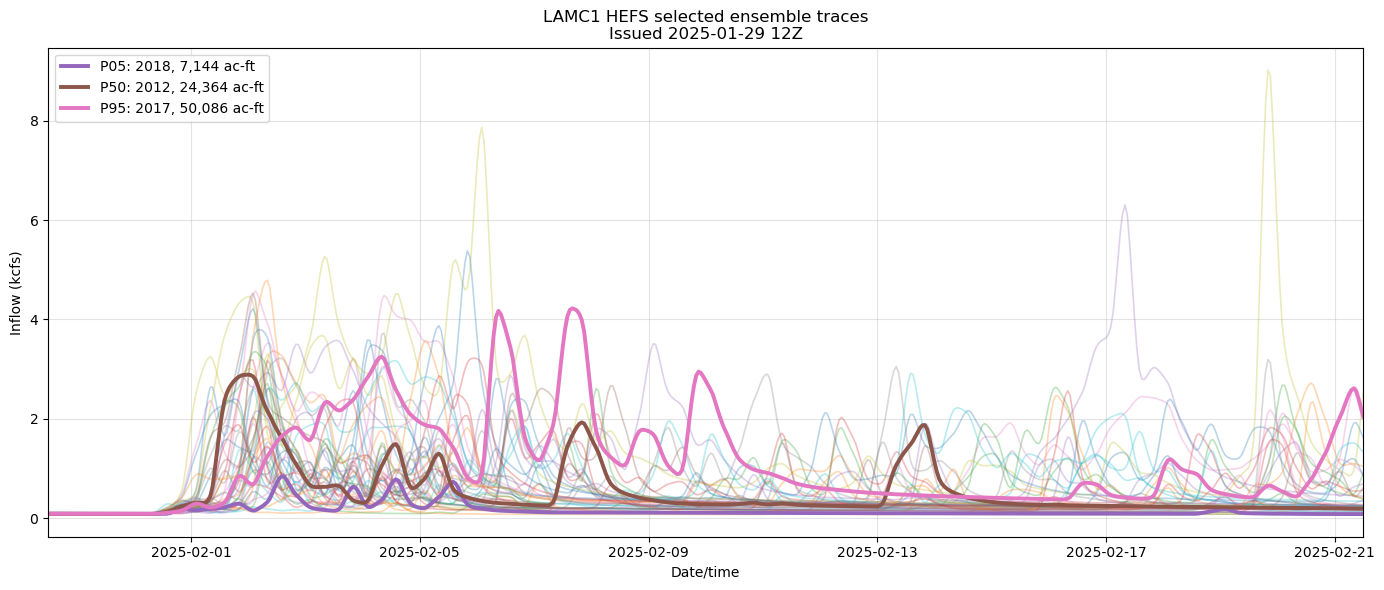

Figure saved: outputs/LAMC1_2025012912_to_2025022112_selected_traces_only.png


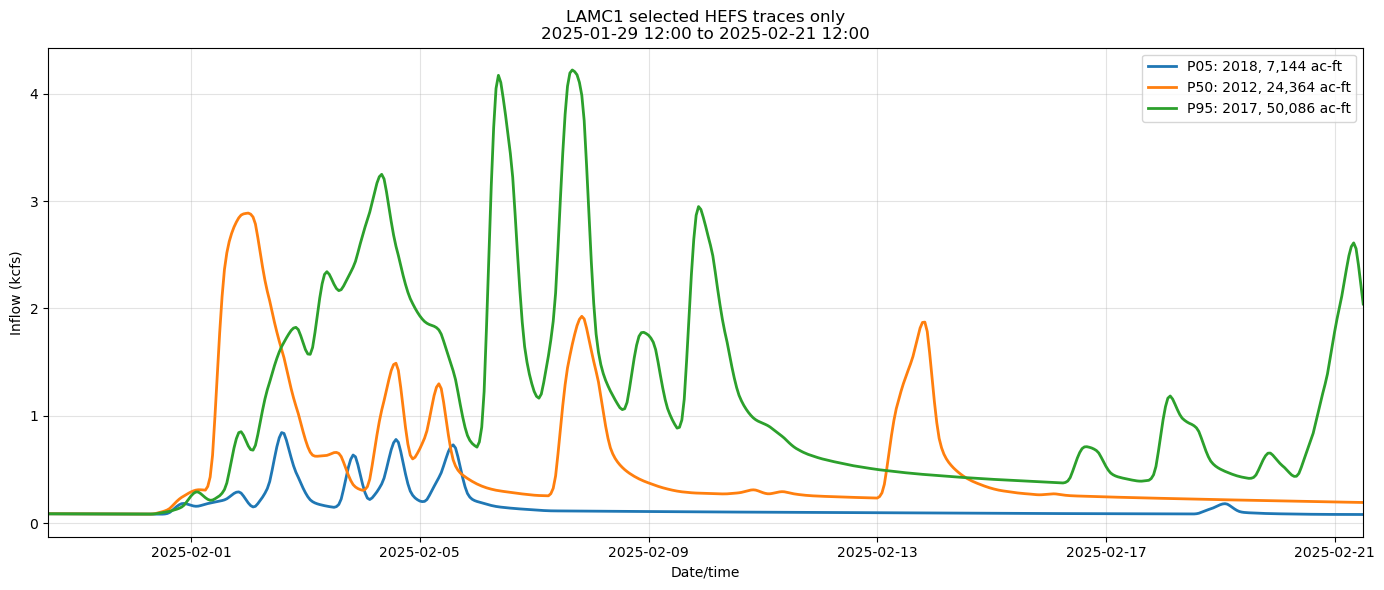


2. Storage and guide-curve analysis

Initial reservoir storage
-------------------------
HEFS start time:        2025-01-29 12:00:00
Storage data time used: 2025-01-29 12:00:00
Initial storage:        79,226 acre-ft
Guide curve:            68,400 acre-ft
Initial exceedance:     10,826 acre-ft
CSV saved: outputs/LAMC1_2025012912_to_2025022112_additional_outflow_needed_timeseries.csv
CSV saved: outputs/LAMC1_2025012912_to_2025022112_additional_outflow_needed_summary.csv

Additional outflow summary
--------------------------


,target_label,ensemble,initial_storage_acreft,guide_curve_storage_acreft,initial_excess_above_guide_curve_acreft,peak_forecast_storage_acreft,peak_storage_time,max_excess_above_guide_curve_acreft,total_additional_outflow_needed_acreft,average_additional_outflow_needed_cfs,max_interval_additional_outflow_cfs,forecast_window_hours,first_exceedance_time
0,P05,2018,79226,68400,10826,86370.125207,2025-02-21 12:00:00,17970.125207,17970.125207,393.910353,839.615,552.0,2025-01-29 12:00:00
1,P50,2012,79226,68400,10826,103589.878512,2025-02-21 12:00:00,35189.878512,35189.878512,771.372337,2887.495,552.0,2025-01-29 12:00:00
2,P95,2017,79226,68400,10826,129312.066529,2025-02-21 12:00:00,60912.066529,60912.066529,1335.210154,4214.980,552.0,2025-01-29 12:00:00


Figure saved: outputs/LAMC1_2025012912_to_2025022112_forecast_storage_vs_guide_curve.png


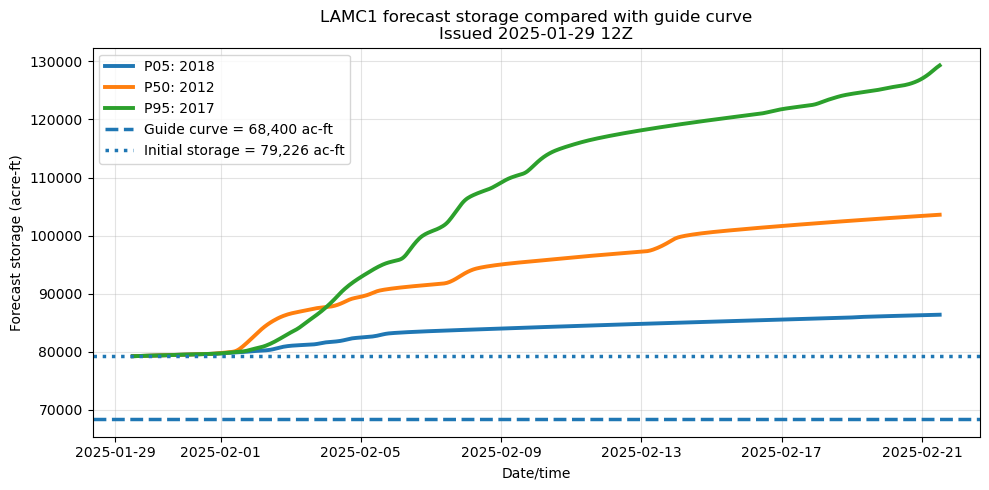

Figure saved: outputs/LAMC1_2025012912_to_2025022112_average_additional_outflow_needed.png


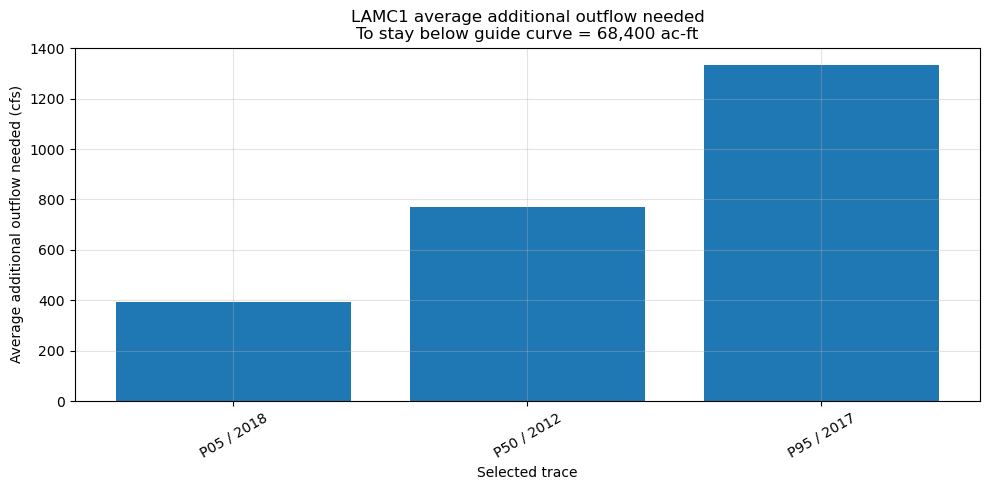

Figure saved: outputs/LAMC1_2025012912_to_2025022112_interval_additional_outflow_needed.png


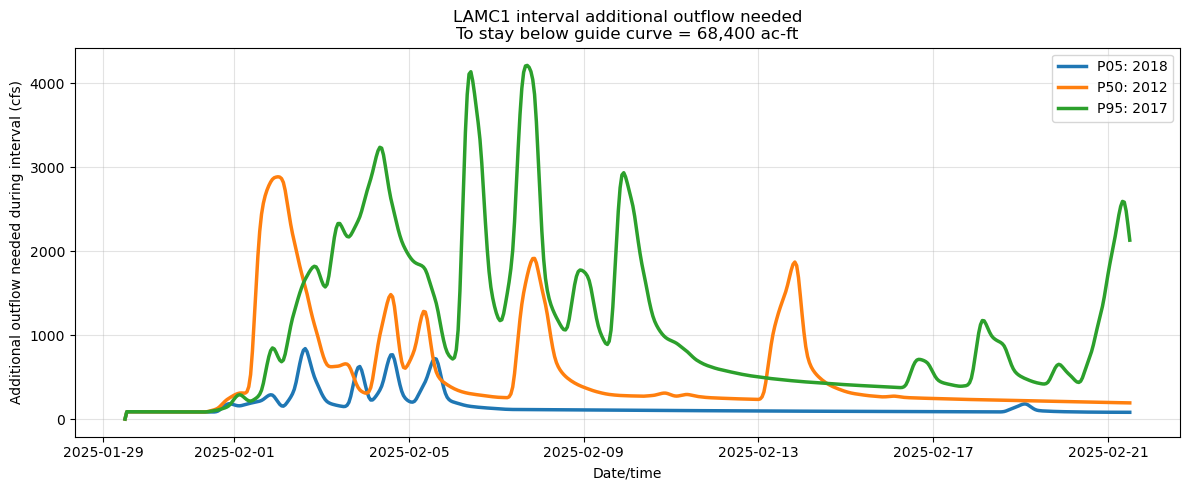


3. Actual outflow comparison

Forecast period
---------------
UTC:   2025-01-29 12:00:00 to 2025-02-21 12:00:00
America/Los_Angeles: 2025-01-29 04:00:00 to 2025-02-21 04:00:00

Observed outflow records in forecast window: 553
Figure saved: outputs/LAMC1_2025012912_to_2025022112_actual_vs_required_outflow.png


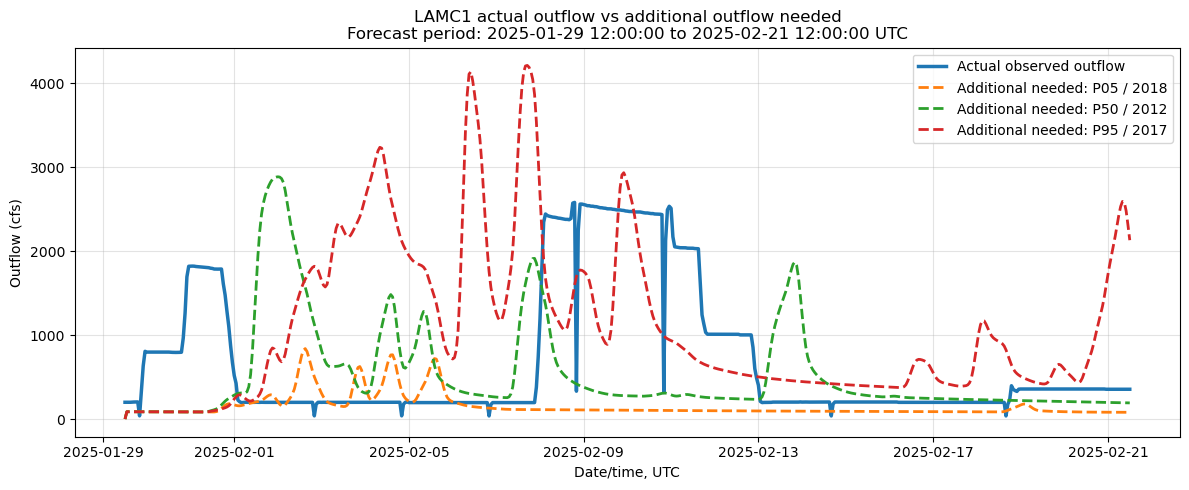

CSV saved: outputs/LAMC1_2025012912_to_2025022112_actual_vs_additional_outflow_comparison_UTC.csv
CSV saved: outputs/LAMC1_2025012912_to_2025022112_actual_vs_additional_outflow_summary_UTC.csv

Actual vs required outflow summary
----------------------------------


,target_label,ensemble,comparison_timezone,max_actual_outflow_cfs,max_additional_outflow_needed_cfs,avg_actual_outflow_cfs,avg_additional_outflow_needed_cfs,percent_time_actual_outflow_exceeded_additional_needed
0,P05,2018,UTC,2582.0,839.615,699.15009,156.318110,82.278481
1,P50,2012,UTC,2582.0,2887.495,699.15009,533.097523,44.665461
2,P95,2017,UTC,2582.0,4214.980,699.15009,1095.915741,30.379747



Workflow complete.
Output folder: /Users/sujanatimilsina/Documents/Sujana_PhD/Hydrolearn/Resources/Test/outputs


In [39]:
# ==================================================
# RUN THE MODULE
# ==================================================
# After editing the USER INPUTS cell, run this cell to generate all tables and plots.

results = run_analysis(CONFIG)

## Main output tables

After the notebook runs, the main tables are available in the `results` dictionary:

- `results["volume_table"]`
- `results["selected_traces"]`
- `results["storage_rise_ts"]`
- `results["additional_outflow_ts"]`
- `results["additional_outflow_summary"]`
- `results["actual_vs_required_comparison"]`
- `results["actual_vs_required_summary"]`

CSV files and PNG figures are saved to the folder set by `CONFIG["output_dir"]`.
